# Clustering Urban Areas

This notebook shows how tessellation can be used to generate clustering units in order to segment urban areas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (8, 8)

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [3]:
from tesspy import Tessellation

## Area

We use **Frankfurt am Main** in Germany as a case study. First, we get the city boundary. 

In [4]:
ffm = Tessellation("Frankfurt am Main")
ffm_polygon = ffm.get_polygon()

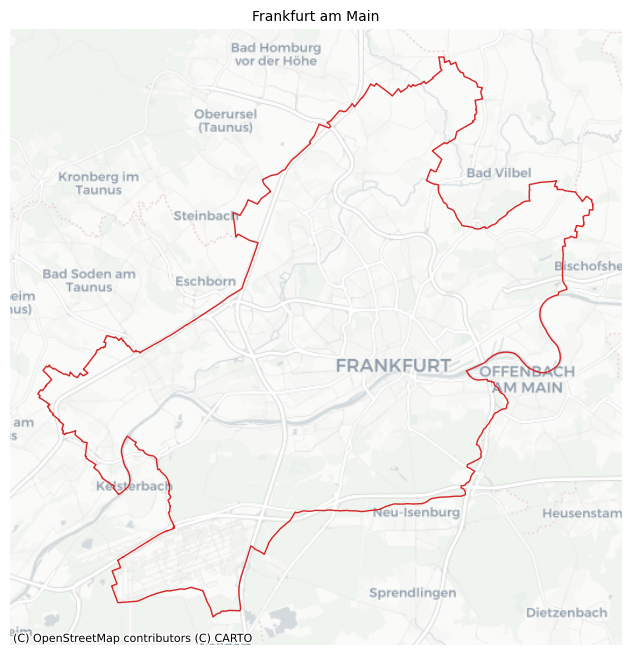

In [5]:
# visualization of area
ax = ffm_polygon.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="tab:red", lw=1)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Frankfurt am Main", fontsize=10)
plt.show()

## Tessellation

We tessellate the area using Voronoi Diagrams.

In [6]:
poi_categories = ["shop", "building", "amenity", "office", "public_transport"]

# voronoi Diagrams
ffm_voronoi_kmeans = ffm.voronoi(poi_categories=poi_categories, n_polygons=1000)

2026-02-22 16:26:48 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=5 n_polygons=1000 min_cluster_size=15 timeout_s=300


2026-02-22 16:26:48 | INFO | tesspy.data.poi | event=poi.fetch.start poi_categories=5 timeout_s=300


2026-02-22 16:44:53 | INFO | tesspy.data.poi | event=poi.fetch.done features=164331 duration_s=438.215


/Users/siavash.saki/Personal/tesspy/tesspy/data/poi.py:118: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


2026-02-22 16:44:54 | INFO | tesspy.data.poi | event=poi.parse.done poi_count=164331


2026-02-22 16:44:56 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans


2026-02-22 16:45:02 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=1000


2026-02-22 16:45:02 | INFO | tesspy._validators | event=geometry.multipolygon.explode


2026-02-22 16:45:02 | INFO | tesspy.tessellation | event=voronoi.done polygons=1002 duration_s=447.148


In [7]:
# adding an ID to tiles
ffm_voronoi_kmeans.reset_index(inplace=True)
ffm_voronoi_kmeans.rename(columns={"index": "tile_id"}, inplace=True)

# check polygons
ffm_voronoi_kmeans.tail()

,tile_id,voronoi_id,geometry
997,997,voronoiID997,"POLYGON ((8.69789 50.09346, 8.6966 50.09023, 8..."
998,998,voronoiID998,"POLYGON ((8.72927 50.08946, 8.72217 50.08244, ..."
999,999,voronoiID999,"POLYGON ((8.62277 50.11096, 8.61704 50.11149, ..."
1000,1000,voronoiID1000,"POLYGON ((8.6668 50.19889, 8.66502 50.19997, 8..."
1001,1001,voronoiID1001,"POLYGON ((8.6919 50.13976, 8.6934 50.13511, 8...."


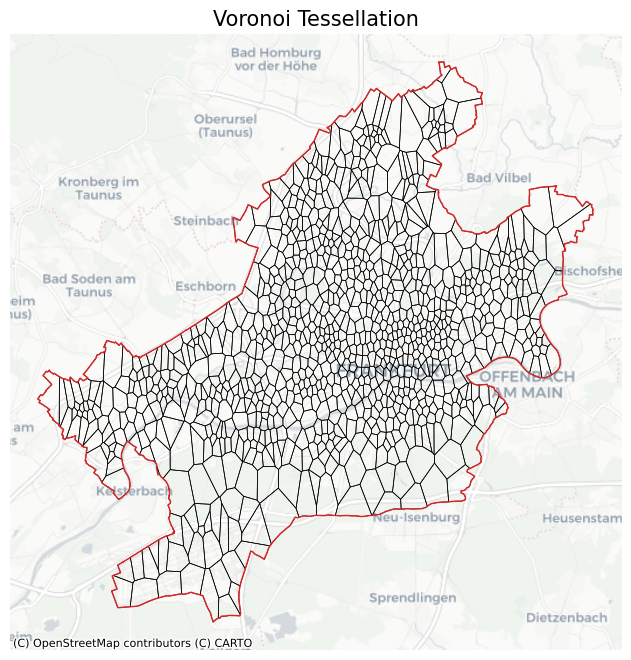

In [8]:
ax = ffm_voronoi_kmeans.to_crs("EPSG:3857").plot(
    facecolor="none", edgecolor="k", lw=0.5
)
ffm_polygon.to_crs("EPSG:3857").plot(ax=ax, facecolor="none", edgecolor="tab:red", lw=1)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Voronoi Tessellation", fontsize=15)
plt.show()

## Data Processing

We create count variables. For each polygon (tile), the number of each POI category is calculated.

In [9]:
# create a GeoDataFrame of POI data
poi_df = ffm.get_poi_data()
poi_geodata = gpd.GeoDataFrame(
    data=poi_df,
    geometry=poi_df[["center_longitude", "center_latitude"]]
    .apply(Point, axis=1)
    .values,
    crs="EPSG:4326",
)

In [10]:
poi_geodata.head()

,center_longitude,center_latitude,shop,building,amenity,office,public_transport,geometry
0,8.568829,50.122765,False,False,False,False,True,POINT (8.56883 50.12277)
1,8.633793,50.153205,False,False,False,False,True,POINT (8.63379 50.1532)
2,8.609222,50.106639,False,False,False,False,True,POINT (8.60922 50.10664)
3,8.620979,50.107860,False,False,False,False,True,POINT (8.62098 50.10786)
4,8.604924,50.108962,False,False,False,False,True,POINT (8.60492 50.10896)


In [11]:
# Count POI
poi_counts = gpd.sjoin(
    ffm_voronoi_kmeans, poi_geodata, how="left", predicate="contains"
)
poi_counts[poi_categories] = poi_counts[poi_categories].map(
    lambda x: np.nan if not x else x
)
poi_counts = poi_counts.groupby(by="tile_id").count().reset_index()
poi_counts.head()

,tile_id,voronoi_id,geometry,index_right,center_longitude,center_latitude,shop,building,amenity,office,public_transport
0,0,117,117,117,117,117,8,79,18,0,12
1,1,230,230,230,230,230,2,150,69,5,12
2,2,343,343,343,343,343,10,183,142,1,9
3,3,275,275,275,275,275,0,273,2,1,0
4,4,247,247,247,247,247,1,234,8,0,6


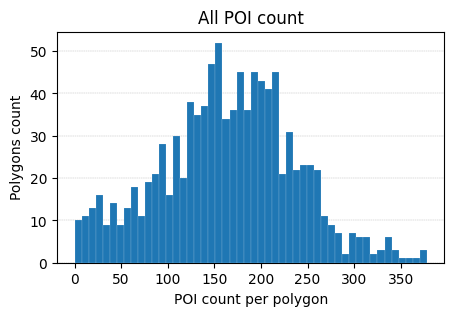

In [12]:
fig, ax = plt.subplots(figsize=(5, 3))
poi_counts["index_right"].plot(
    kind="hist", bins=50, ax=ax, lw=0.1, edgecolor="white", zorder=3
)
ax.set_title("All POI count")
ax.set_xlabel("POI count per polygon")
ax.set_ylabel("Polygons count")
ax.grid(axis="y", lw=0.3, ls="--", zorder=0)

We normalize the data using `MinMaxScaler`.

In [13]:
data = poi_counts[poi_categories].values
data_norm = MinMaxScaler().fit_transform(data)

## Clustering

K-Means is used for clustering polygons. 

In [14]:
kmc = KMeans(n_clusters=4, random_state=0).fit(data_norm)

In [15]:
clustering_results = gpd.GeoDataFrame(
    geometry=ffm_voronoi_kmeans["geometry"], data=poi_counts[poi_categories]
)
clustering_results["cluster"] = kmc.labels_

# pretiffy the results
dct_ = dict(
    zip(
        clustering_results.groupby("cluster")
        .count()
        .sort_values("geometry", ascending=False)
        .index,
        clustering_results.groupby("cluster").count().index,
    )
)


def sort_class_labels(i, dct):
    return dct[i]


clustering_results["cluster"] = clustering_results["cluster"].apply(
    lambda x: sort_class_labels(x, dct_)
)

## Results

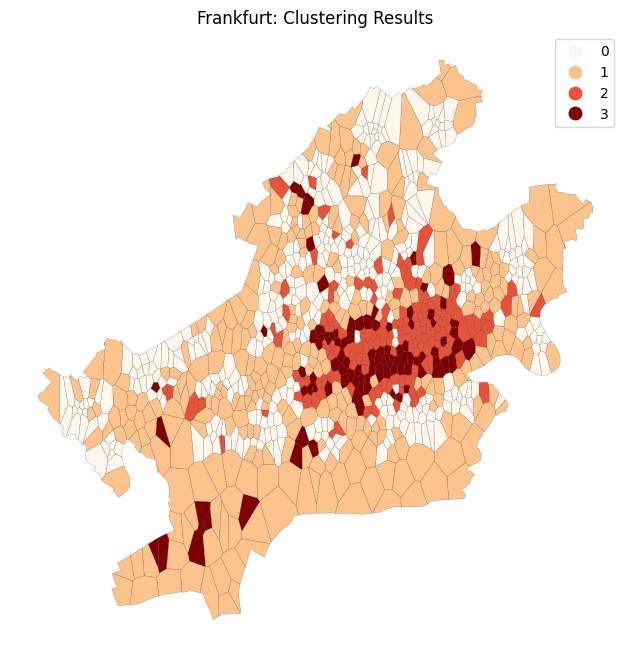

In [16]:
fig, ax = plt.subplots()
ax.set_axis_off()
clustering_results.plot(
    column="cluster",
    categorical=True,
    cmap="OrRd",
    linewidth=0.1,
    edgecolor="k",
    legend=True,
    ax=ax,
)
ax.set_title(f"Frankfurt: Clustering Results")
plt.show()

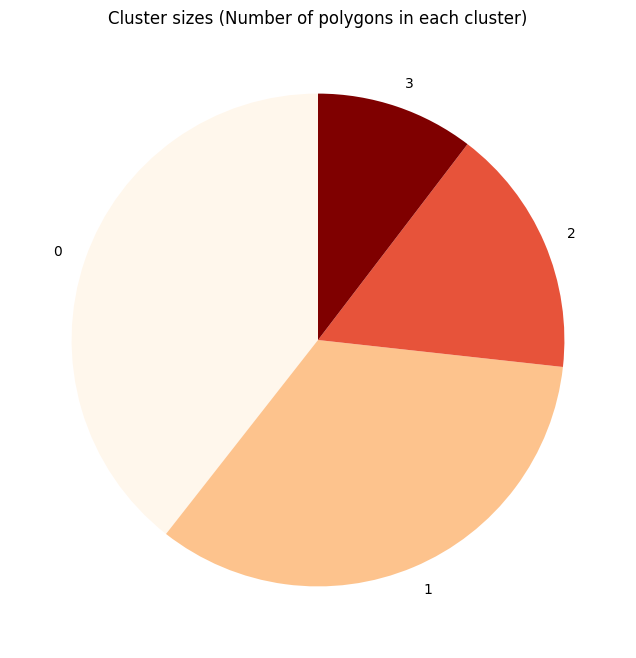

In [17]:
from matplotlib import cm

cs = cm.OrRd(np.linspace(0, 1, 4))

fig, ax = plt.subplots()
labels = clustering_results["cluster"].value_counts().index
sizes = clustering_results["cluster"].value_counts().values
ax.pie(sizes, labels=labels, startangle=90, colors=cs)
ax.set_title(f"Cluster sizes (Number of polygons in each cluster)")

plt.show()

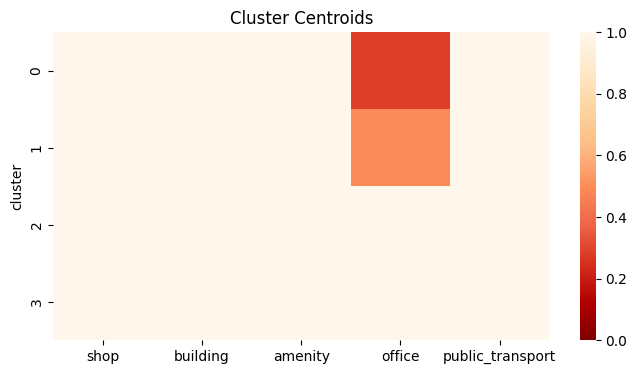

In [18]:
cluster_centroids = clustering_results.groupby("cluster").mean(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cluster_centroids, ax=ax, cmap="OrRd_r", vmin=0, vmax=1)
ax.set_title(f"Cluster Centroids")
plt.show()